<a href="https://colab.research.google.com/github/Garxxss/ml-uni/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9611_%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B8_%D1%81%D0%B5%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F_%D0%BA%D0%BB%D0%B8%D0%B5%D0%BD%D1%82%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%BE%D0%B2_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №11. Анализ и сегментация клиентов с помощью алгоритмов кластеризации**

### **Цель работы:**

Разработать систему сегментации клиентов для розничной компании с использованием алгоритмов кластеризации. Это позволит компании лучше понимать своих клиентов, персонализировать маркетинговые кампании и оптимизировать бизнес-процессы.

### **Введение:**

Розничные компании сталкиваются с большим объемом данных о своих клиентах, включая историю покупок, демографическую информацию и поведенческие характеристики. Однако без должного анализа эти данные остаются неиспользованными. Сегментация клиентов позволяет выделить группы с общими характеристиками, чтобы более эффективно таргетировать предложения и улучшить удовлетворенность клиентов.



### **Задачи:**

1. **Сбор и анализ данных о клиентах.**
2. **Предобработка и подготовка данных для моделирования.**
3. **Применение различных алгоритмов кластеризации для сегментации клиентов.**
4. **Оценка качества кластеризации с использованием внутренних и внешних метрик.**
5. **Интерпретация и визуализация результатов.**
6. **Формирование рекомендаций для бизнес-стратегии компании на основе полученных сегментов.**



### **Пошаговое описание рабочего процесса (пайплайна):**

#### **Шаг 1: Сбор и анализ данных**

**1.1. Выбор набора данных:**

- Используйте датасет "Online Retail II" из [UCI Machine Learning Repository](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) или [другой открытый набор данных](https://archive.ics.uci.edu/datasets?Task=Clustering&skip=0&take=10&sort=desc&orderBy=NumHits&search=&Area=Business), содержащий информацию о транзакциях клиентов.
- Данные должны включать:
  - Идентификаторы клиентов.
  - Информацию о покупках (товары, количество, стоимость).
  - Дату и время транзакций.
  - Демографические данные (если доступны): возраст, пол, локация и т.д.

**1.2. Первичный анализ данных (EDA):**

- Изучите структуру данных и их распределение.
- Определите основные характеристики данных:
  - Общий объем продаж.
  - Частота покупок по клиентам.
  - Распределение выручки по товарам.
- Выявите тенденции и аномалии.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
import seaborn as sns
from IPython.display import HTML, display
from mpl_toolkits.mplot3d import Axes3D
from plotly.subplots import make_subplots
from sklearn import (cluster, decomposition, ensemble, linear_model, manifold,
                     metrics, mixture, model_selection, pipeline,
                     preprocessing)

warnings.filterwarnings("ignore")

plt.rcParams["patch.force_edgecolor"] = True

In [ ]:
import requests
import zipfile
import io
import pandas as pd

# Ссылка на архив
url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"

response = requests.get(url, verify=False)

with zipfile.ZipFile(io.BytesIO(response.content)) as zfile:
    zfile.extractall()

data = pd.read_excel("online_retail_II.xlsx")
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


#### **Шаг 2: Предобработка данных**

**2.1. Работа с пропущенными значениями:**

- Проанализируйте наличие пропущенных данных.
- Решите, как справиться с ними:
  - Удаление строк/столбцов с пропущенными значениями.
  - Заполнение пропущенных значений средним, медианой или наиболее частым значением.

**2.2. Обработка выбросов:**

- Выявите выбросы в данных (например, аномально большие заказы).
- Решите, следует ли их удалить или обработать иным образом.

**2.3. Создание новых признаков:**

- Рассчитайте Recency, Frequency, Monetary Value (RFM-анализ):
  - **Recency (давность):** Время с момента последней покупки.
  - **Frequency (частота):** Количество покупок за определенный период.
  - **Monetary (сумма):** Общая сумма покупок.
- Создайте дополнительные признаки, такие как средний чек, предпочтительные категории товаров и т.д.

**2.4. Нормализация и масштабирование:**

- Примените стандартизацию или нормализацию к числовым признакам для приведения их к единому масштабу.
- Объясните выбор метода масштабирования.

In [ ]:
data.isnull().sum() # Ответ: Description, CustomerID.

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [ ]:
# 2.1
display(data.isnull().sum())
print('Сколько потеряем данных в %, если удалить данные признаки')
display(data.isnull().sum()*100/data.shape[0])

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


Сколько потеряем данных в %, если удалить данные признаки


,0
Invoice,0.000000
StockCode,0.000000
Description,0.557225
Quantity,0.000000
InvoiceDate,0.000000
Price,0.000000
Customer ID,20.539488
Country,0.000000


In [ ]:
data.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [ ]:
data = data.dropna(subset=['Customer ID'])

print(f"Количество полностью дублированных записей: {data.duplicated().value_counts()[1]}")
data.drop_duplicates(inplace=True)

Количество полностью дублированных записей: 6771


In [ ]:
# 2.3
def get_quantity_canceled(data):
    """
    Функция проходит по всем транзакциям-возвратам в рамках каждой группы
    (Customer ID, StockCode) и ищет покупку (или покупки) с более ранней датой
    и подходящим количеством товара. В результате возвращает Series, где
    для каждой «положительной» записи (покупки) указывается, сколько товаров
    вернули позднее.
    """
    quantity_canceled = pd.Series(0, index=data.index, dtype=int)

    grouped = data.groupby(['Customer ID', 'StockCode'], group_keys=False)

    def process_group(df_group):
        df_group = df_group.sort_values('InvoiceDate')

        positives = df_group[df_group['Quantity'] > 0]
        negatives = df_group[df_group['Quantity'] < 0]

        for neg_idx, neg_row in negatives.iterrows():
            candidates = positives[positives['InvoiceDate'] < neg_row['InvoiceDate']]
            if candidates.empty:
                continue

            if len(candidates) == 1:
                quantity_canceled.at[candidates.index[0]] = -neg_row['Quantity']
            else:
                candidates = candidates.sort_index(ascending=False)
                for pos_idx, pos_row in candidates.iterrows():
                    if pos_row['Quantity'] >= -neg_row['Quantity']:
                        quantity_canceled.at[pos_idx] = -neg_row['Quantity']
                        break

        return df_group

    grouped.apply(process_group)

    return quantity_canceled

data['QuantityCanceled'] = get_quantity_canceled(data)

In [ ]:
data_cleaned = data[data['Quantity'] > 0].copy()
data_cleaned = data_cleaned[data_cleaned['Price'] != 0]

data_cleaned['InvoiceDate'] = pd.to_datetime(data_cleaned['InvoiceDate'])
data_cleaned['TotalPrice'] = data_cleaned['Price'] * (
    data_cleaned['Quantity'] - data_cleaned['QuantityCanceled']
)
data_cleaned['Date'] = data_cleaned['InvoiceDate'].dt.date

In [ ]:
now = pd.to_datetime("2010-12-10")

custom_aggregation = {
    "InvoiceDate": lambda x: (now - x.max()).days,  # Recency
    "Invoice": lambda x: x.nunique(),            # Frequency
    "Price": "sum",                           # Monetary
}

rfm_table = (
    data
    .groupby("Customer ID")
    .agg(custom_aggregation)
    .rename(columns={
        "InvoiceDate": "Recency",
        "Invoice": "Frequency",
        "Price": "Monetary",
        "Quantity": "MeanQuantity"
    })
)

rfm_table.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,66,15,565.42
12347.0,2,2,162.95
12348.0,73,1,14.39
12349.0,42,4,899.49
12351.0,10,1,49.46


In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots

# Выбираем столбцы для построения коробчатых диаграмм
columns_to_plot = ["Recency", "Frequency", "Monetary"]

# Создаём коробчатые диаграммы для каждого из выбранных признаков
boxes = [px.box(rfm_table, x=col) for col in columns_to_plot]

# Формируем макет из трёх подположений
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Recency", "Frequency", "Monetary")
)

# Добавляем каждую диаграмму в свой подплот
for i, box_fig in enumerate(boxes):
    fig.add_trace(box_fig.data[0], row=1, col=i+1)

# Настраиваем и выводим итоговую диаграмму
fig.update_layout(showlegend=True)
fig.write_html("boxplot_1.html")
fig.show()

In [ ]:
display(rfm_table.info())
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4383 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4383 non-null   int64  
 1   Frequency  4383 non-null   int64  
 2   Monetary   4383 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 137.0 KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Invoice           400916 non-null  object        
 1   StockCode         400916 non-null  object        
 2   Description       400916 non-null  object        
 3   Quantity          400916 non-null  int64         
 4   InvoiceDate       400916 non-null  datetime64[ns]
 5   Price             400916 non-null  float64       
 6   Customer ID       400916 non-null  float64       
 7   Country           400916 non-null  object        
 8   QuantityCanceled  400916 non-null  int64         
 9   TotalPrice        400916 non-null  float64       
 10  Date              400916 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 36.7+ MB


In [ ]:
# 1) Определяем 95-е квантили для Monetary, Frequency, Recency
h_cap_monetary = rfm_table["Monetary"].quantile(0.95)
h_cap_frequency = rfm_table["Frequency"].quantile(0.95)
h_cap_recency = rfm_table["Recency"].quantile(0.95)

# 2) Отбираем выбросы
outliers = rfm_table[
    (rfm_table["Monetary"] > h_cap_monetary) |
    (rfm_table["Frequency"] > h_cap_frequency) |
    (rfm_table["Frequency"] > h_cap_frequency)
]

# 3) Удаляем выбросы из RFM-таблицы
rfm_table_cleaned = rfm_table.drop(outliers.index)

# 4) Выводим количество оставшихся записей (клиентов)
print(f"После удаления выбросов осталось {rfm_table_cleaned.shape[0]} клиентов в RFM-таблице.")
# По условию задачи ответ: 4044

После удаления выбросов осталось 4065 клиентов в RFM-таблице.


In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots

# Формируем список диаграмм для выбранных столбцов RFM-таблицы
columns_to_plot = ["Recency", "Frequency", "Monetary"]
boxes = [px.box(rfm_table_cleaned, x=col) for col in columns_to_plot]

# Создаём макет для трёх коробчатых диаграмм
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Recency", "Frequency", "Monetary")
)

# Добавляем каждую коробчатую диаграмму в соответствующее подполе
for i, box_fig in enumerate(boxes):
    fig.add_trace(box_fig.data[0], row=1, col=i+1)

# Настраиваем внешний вид и отображаем результат
fig.update_layout(showlegend=True)
fig.write_html("boxplot_2.html")
fig.show()

In [ ]:
# 2.4
from sklearn.preprocessing import StandardScaler

features = ['Recency', 'Frequency', 'Monetary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_table_cleaned[features])

Обоснование выбора метода масштабирования

Показатели RFM имеют разные единицы измерения и существенно отличаются по диапазону значений. Параметр Recency выражается в днях и может принимать значения от десятков до сотен, Frequency отражает количество покупок и обычно находится в диапазоне единиц или десятков, тогда как Monetary измеряется в денежных единицах и нередко достигает сотен или тысяч. Если не выполнить масштабирование, наибольшее влияние на результаты анализа будет оказывать именно Monetary, что приведёт к дисбалансу при построении кластеров.

Поскольку на этапе предварительной обработки были исключены аномальные наблюдения (значения выше 95-го перцентиля), использование StandardScaler является оправданным решением. Несмотря на чувствительность данного метода к выбросам, после их удаления этот недостаток практически не влияет на качество преобразования данных. В свою очередь, MinMaxScaler приводит все признаки к диапазону от 0 до 1, что может чрезмерно сгладить различия между объектами и негативно сказаться на точности кластеризации.

#### **Шаг 3: Применение алгоритмов кластеризации**

**3.1. Выбор алгоритмов:**

- **K-средних (K-Means):** Для разбиения данных на k кластеров на основе эврестического подхода.
- **Иерархическая кластеризация:** Для выявления вложенной структуры кластеров.
- **DBSCAN и OPTICS:** Для обнаружения кластеров произвольной формы и выявления выбросов.

**3.2. Определение оптимального количества кластеров:**

- Для K-Means и иерархической кластеризации используйте:
  - **Метод локтя (Elbow Method):** Постройте график зависимости суммы квадратов внутрикластерных расстояний от числа кластеров.
  - **Коэффициент силуэта:** Рассчитайте для различных значений k и выберите оптимальное.

**3.3. Применение алгоритмов:**

- Запустите каждый алгоритм на подготовленных данных.
- Сохраняйте результаты кластеризации для последующего анализа.

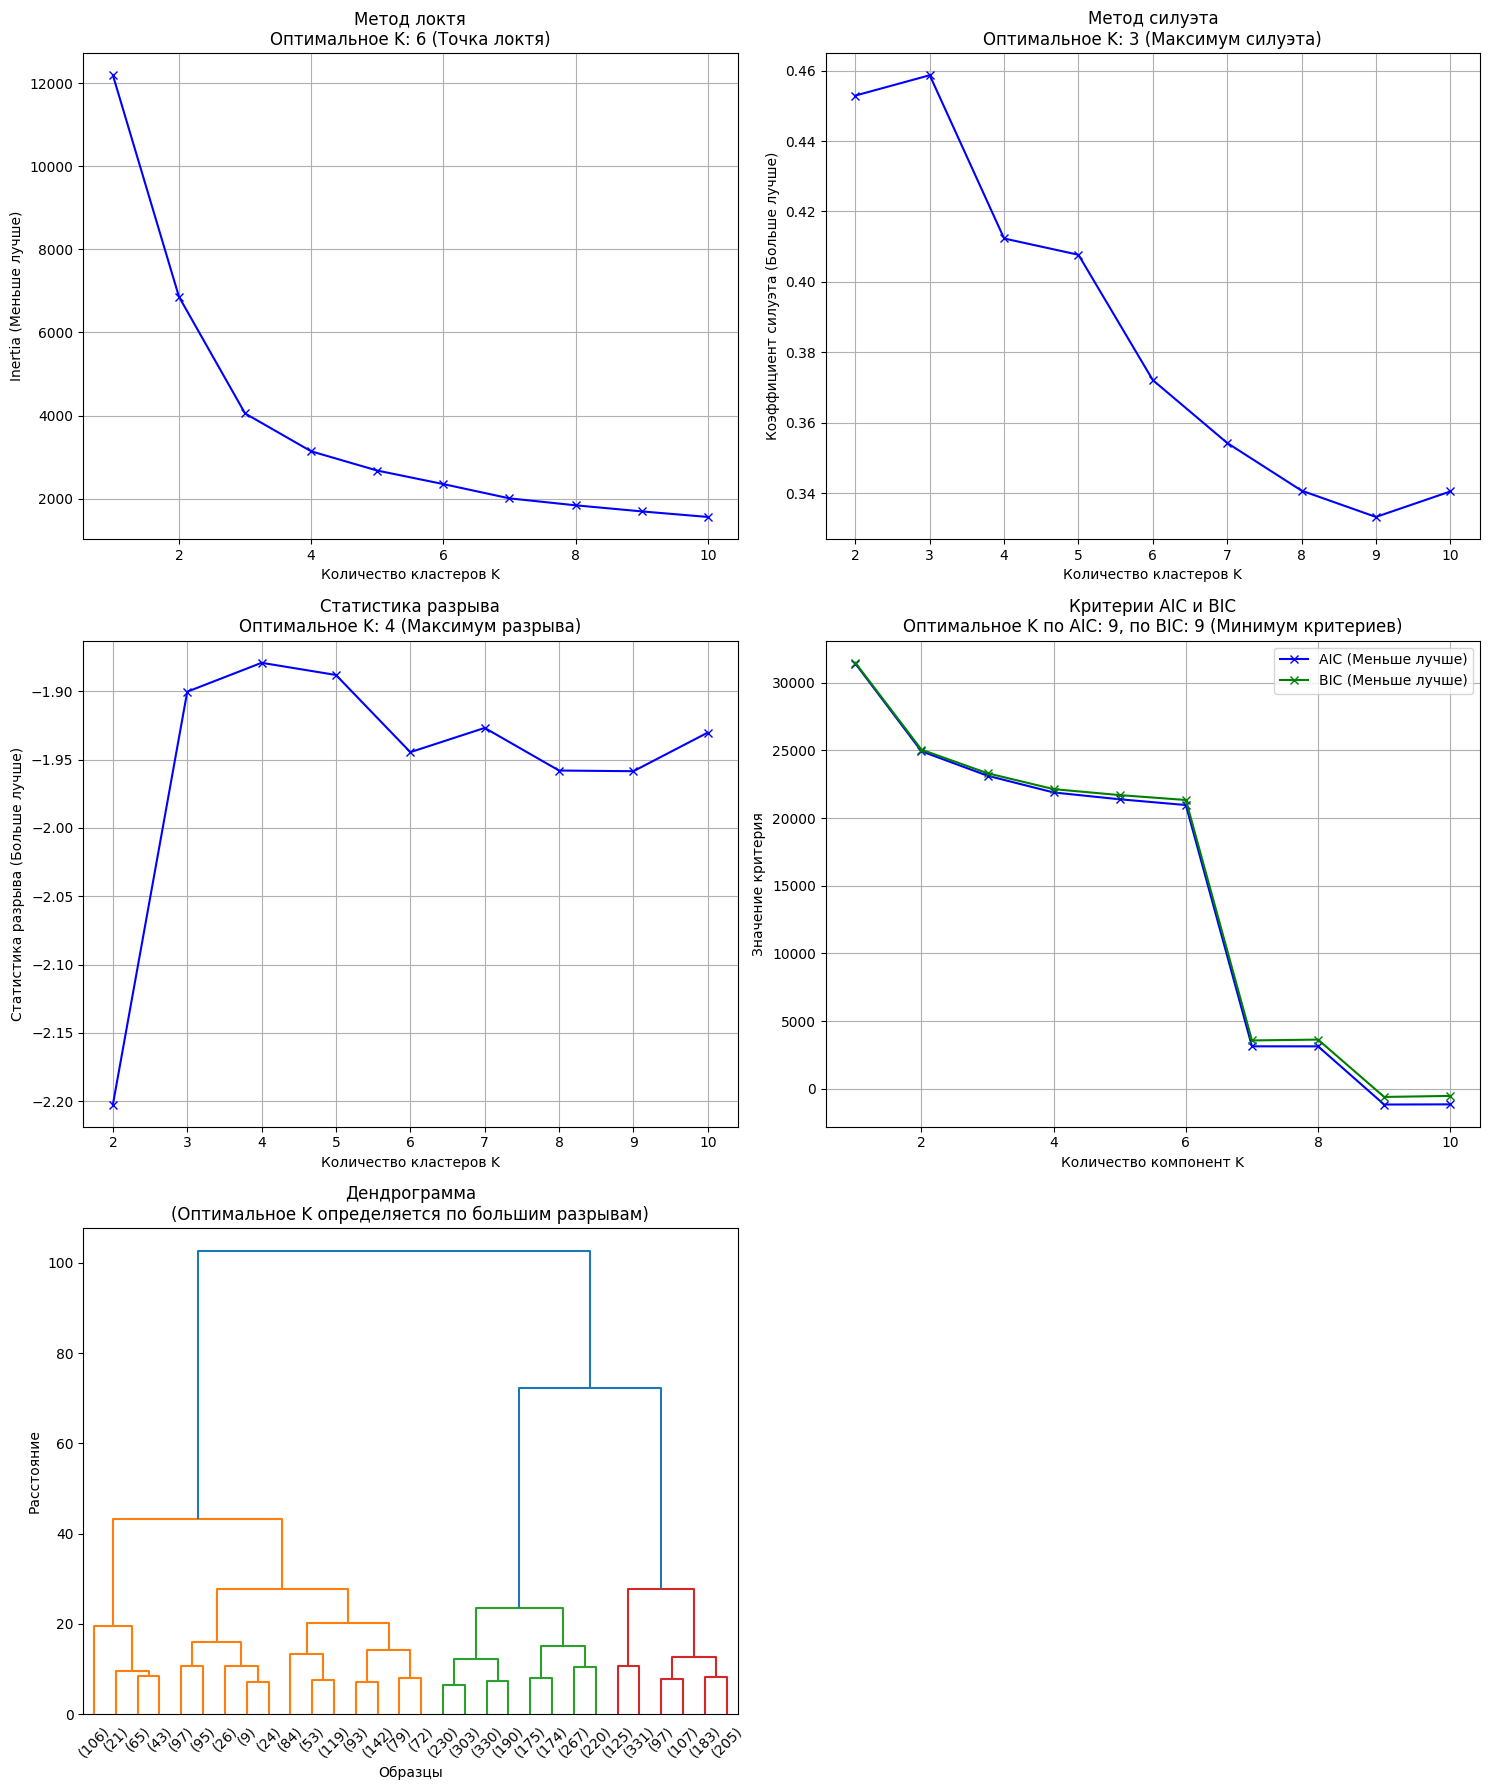

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Стандартизация данных
X = X_scaled

# Диапазон чисел кластеров для анализа
K = range(1, 11)

# 1. Метод локтя (Elbow Method)
inertia = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Определение оптимального K по методу локтя
diff_inertia = np.diff(inertia)
diff_diff_inertia = np.diff(diff_inertia)
elbow_point = np.argmin(diff_diff_inertia) + 2  # +2 из-за порядка дифференцирования

# 2. Метод силуэта (Silhouette Method)
silhouette_scores = []
K_silhouette = range(2, 11)  # Силуэт не определяется для k=1
for k in K_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Определение оптимального K по методу силуэта
optimal_k_silhouette = K_silhouette[np.argmax(silhouette_scores)]

# 3. Статистика разрыва (Gap Statistic)
def compute_gap_statistic(X, nrefs=5, max_clusters=10):
    gaps = np.zeros(max_clusters - 1)
    results = np.zeros(max_clusters - 1)
    for k in range(1, max_clusters):
        km = KMeans(n_clusters=k+1, random_state=42)
        km.fit(X)
        disp = km.inertia_
        results[k - 1] = disp

        ref_disps = np.zeros(nrefs)
        for i in range(nrefs):
            random_reference = np.random.random_sample(size=X.shape)
            km_ref = KMeans(n_clusters=k+1, random_state=42)
            km_ref.fit(random_reference)
            ref_disp = km_ref.inertia_
            ref_disps[i] = ref_disp
        gap = np.log(np.mean(ref_disps)) - np.log(disp)
        gaps[k - 1] = gap
    return gaps

gaps = compute_gap_statistic(X, nrefs=5, max_clusters=10)
K_gap = range(2, 11)

# Определение оптимального K по статистике разрыва
optimal_k_gap = K_gap[np.argmax(gaps)]

# 4. Критерии AIC и BIC для моделей смеси гауссовых распределений
aic_scores = []
bic_scores = []
for k in K:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X)
    aic_scores.append(gmm.aic(X))
    bic_scores.append(gmm.bic(X))

# Определение оптимального K по AIC и BIC
optimal_k_aic = K[np.argmin(aic_scores)]
optimal_k_bic = K[np.argmin(bic_scores)]

# 5. Иерархическая кластеризация с дендрограммой
linked = linkage(X, 'ward')

# Построение графиков
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# График 1: Метод локтя
axes[0, 0].plot(K, inertia, 'bx-')
axes[0, 0].set_xlabel('Количество кластеров K')
axes[0, 0].set_ylabel('Inertia (Меньше лучше)')
axes[0, 0].set_title(f'Метод локтя\nОптимальное K: {elbow_point} (Точка локтя)')
axes[0, 0].grid(True)

# График 2: Метод силуэта
axes[0, 1].plot(K_silhouette, silhouette_scores, 'bx-')
axes[0, 1].set_xlabel('Количество кластеров K')
axes[0, 1].set_ylabel('Коэффициент силуэта (Больше лучше)')
axes[0, 1].set_title(f'Метод силуэта\nОптимальное K: {optimal_k_silhouette} (Максимум силуэта)')
axes[0, 1].grid(True)

# График 3: Статистика разрыва
axes[1, 0].plot(K_gap, gaps, 'bx-')
axes[1, 0].set_xlabel('Количество кластеров K')
axes[1, 0].set_ylabel('Статистика разрыва (Больше лучше)')
axes[1, 0].set_title(f'Статистика разрыва\nОптимальное K: {optimal_k_gap} (Максимум разрыва)')
axes[1, 0].grid(True)

# График 4: Критерии AIC и BIC
axes[1, 1].plot(K, aic_scores, 'bx-', label='AIC (Меньше лучше)')
axes[1, 1].plot(K, bic_scores, 'gx-', label='BIC (Меньше лучше)')
axes[1, 1].set_xlabel('Количество компонент K')
axes[1, 1].set_ylabel('Значение критерия')
axes[1, 1].set_title(f'Критерии AIC и BIC\nОптимальное K по AIC: {optimal_k_aic}, по BIC: {optimal_k_bic} (Минимум критериев)')
axes[1, 1].legend()
axes[1, 1].grid(True)

# График 5: Дендрограмма
dendrogram(linked, ax=axes[2, 0], truncate_mode='lastp', p=30)
axes[2, 0].set_title('Дендрограмма\n(Оптимальное K определяется по большим разрывам)')
axes[2, 0].set_xlabel('Образцы')
axes[2, 0].set_ylabel('Расстояние')

fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()

**По методу локтя и методу силуэта оптимальное K = 3; 4**

In [ ]:
optimal_k = 3

In [ ]:
# KMeans c разными K близкими к оптимальному
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans1 = KMeans(n_clusters=optimal_k+1, random_state=42, n_init=10)
kmeans2 = KMeans(n_clusters=optimal_k+2, random_state=42, n_init=10)
rfm_table_cleaned['cluster_km'] = kmeans.fit_predict(X_scaled)
rfm_table_cleaned['cluster_km1'] = kmeans1.fit_predict(X_scaled)
rfm_table_cleaned['cluster_km2'] = kmeans2.fit_predict(X_scaled)

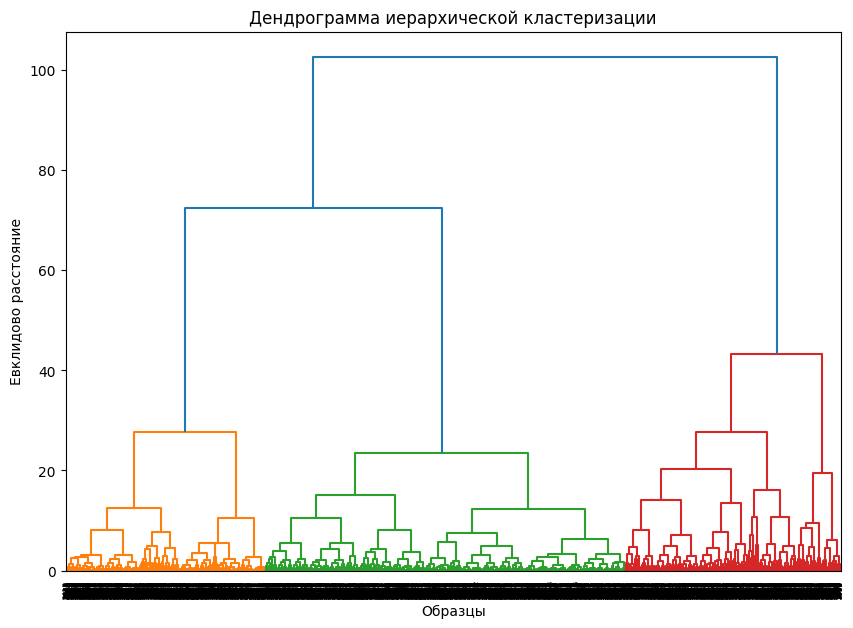

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Вычисление матрицы связей для построения дендрограммы
linked = linkage(X_scaled, method='ward')

# Построение дендрограммы
plt.figure(figsize=(10, 7))
dendrogram(linked,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Образцы')
plt.ylabel('Евклидово расстояние')
plt.show()

# Применение иерархической кластеризации с исправлением параметра
hc = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
hc1 = AgglomerativeClustering(n_clusters=optimal_k+1, metric='euclidean', linkage='ward')
hc2 = AgglomerativeClustering(n_clusters=optimal_k+2, metric='euclidean', linkage='ward')
rfm_table_cleaned['cluster_hc'] = hc.fit_predict(X_scaled)
rfm_table_cleaned['cluster_hc1'] = hc1.fit_predict(X_scaled)
rfm_table_cleaned['cluster_hc2'] = hc2.fit_predict(X_scaled)

In [ ]:
# DBSCAN с несколькими K близкими к оптимальному
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.62, min_samples=3)
dbscan1 = DBSCAN(eps=0.52, min_samples=3)
dbscan2 = DBSCAN(eps=0.45, min_samples=3)
rfm_table_cleaned['cluster_db'] = dbscan.fit_predict(X_scaled)
rfm_table_cleaned['cluster_db1'] = dbscan1.fit_predict(X_scaled)
rfm_table_cleaned['cluster_db2'] = dbscan2.fit_predict(X_scaled)

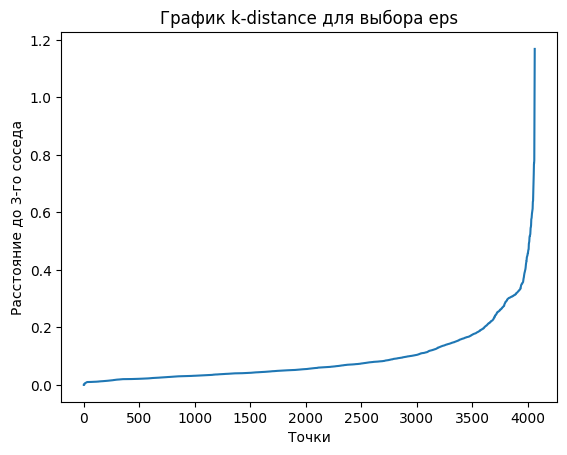

In [ ]:
# eps на изгибе графика
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=3)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 2], axis=0)
plt.plot(distances)
plt.xlabel('Точки')
plt.ylabel('Расстояние до 3-го соседа')
plt.title('График k-distance для выбора eps')
plt.show()

#### **Шаг 4: Оценка качества кластеризации**

**4.1. Внутренние метрики:**

- **Коэффициент силуэта:** Оцените, насколько хорошо объекты расположены внутри кластеров.
- **Индекс Дэвиса-Болдина:** Оцените уровень разделимости кластеров.
- **Индекс Калинского-Харабаза:** Оцените соотношение межкластерной дисперсии к внутрикластерной.

**4.2. Внешние метрики (если доступны истинные метки):**

- **Adjusted Rand Index (ARI):** Сравните полученные кластеры с известными категориями клиентов.
- **Normalized Mutual Information (NMI):** Измерьте общую информацию между распределениями.

**4.3. Сравнение алгоритмов:**

- Составьте таблицу со значениями метрик для каждого алгоритма.
- Определите, какой алгоритм показал наилучшие результаты и почему.

In [ ]:
#4 Оценка качества кластеризации

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import cdist, pdist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Функция расчёта всех внутренних метрик
def compute_internal_metrics(X, labels, algorithm_name):
    """
    Рассчитывает основные внутренние метрики качества кластеризации.
    Для алгоритмов, которые могут выдавать шум (-1), исключает их.
    """
    mask = labels != -1
    X_clean = X[mask]
    labels_clean = labels[mask]

    unique_clusters = np.unique(labels_clean)
    n_clusters = len(unique_clusters)

    if n_clusters < 2 or len(X_clean) == 0:
        return {
            'Алгоритм': algorithm_name,
            'Количество кластеров': n_clusters,
            'Коэффициент силуэта': np.nan,
            'Индекс Дэвиса-Болдина': np.nan,
            'Индекс Калинского-Харабаза': np.nan,
        }

    return {
        'Алгоритм': algorithm_name,
        'Количество кластеров': n_clusters,
        'Коэффициент силуэта': silhouette_score(X_clean, labels_clean),
        'Индекс Дэвиса-Болдина': davies_bouldin_score(X_clean, labels_clean),
        'Индекс Калинского-Харабаза': calinski_harabasz_score(X_clean, labels_clean),
    }


results_list = []

# KMeans (3 варианта)
results_list.append(compute_internal_metrics(X_scaled, rfm_table_cleaned['cluster_km'], 'KMeans_K=3'))
results_list.append(compute_internal_metrics(X_scaled, rfm_table_cleaned['cluster_km1'], 'KMeans_K=4'))
results_list.append(compute_internal_metrics(X_scaled, rfm_table_cleaned['cluster_km2'], 'KMeans_K=5'))

# AgglomerativeClustering (3 варианта)
results_list.append(compute_internal_metrics(X_scaled, rfm_table_cleaned['cluster_hc'], 'Agglomerative_K=3'))
results_list.append(compute_internal_metrics(X_scaled, rfm_table_cleaned['cluster_hc1'], 'Agglomerative_K=4'))
results_list.append(compute_internal_metrics(X_scaled, rfm_table_cleaned['cluster_hc2'], 'Agglomerative_K=5'))

# DBSCAN (3 варианта параметров)
results_list.append(compute_internal_metrics(X_scaled, rfm_table_cleaned['cluster_db'], 'DBSCAN_eps=0.62'))
results_list.append(compute_internal_metrics(X_scaled, rfm_table_cleaned['cluster_db1'], 'DBSCAN_eps=0.52'))
results_list.append(compute_internal_metrics(X_scaled, rfm_table_cleaned['cluster_db2'], 'DBSCAN_eps=0.45'))

metrics_df = pd.DataFrame(results_list)
metrics_df


,Алгоритм,Количество кластеров,Коэффициент силуэта,Индекс Дэвиса-Болдина,Индекс Калинского-Харабаза
0,KMeans_K=3,3,0.458677,0.785707,4085.253999
1,KMeans_K=4,4,0.413336,0.920982,3907.245745
2,KMeans_K=5,5,0.407664,0.935709,3613.705784
3,Agglomerative_K=3,3,0.429721,0.818539,3698.732121
4,Agglomerative_K=4,4,0.421870,0.920882,3523.495485
5,Agglomerative_K=5,5,0.418933,1.068260,3111.315384
6,DBSCAN_eps=0.62,4,0.108339,0.809338,5.916908
7,DBSCAN_eps=0.52,2,0.244192,0.854524,10.240114
8,DBSCAN_eps=0.45,5,0.102137,0.714637,8.275577


In [ ]:
# Результат KMeans_K=3 - лучшая модель кластеризции
# Силуэт	0.459 (самый высокий)	Объекты хорошо сгруппированы
# Дэвис-Болдин	0.786 (самый низкий)	Кластеры компактные и разделённые
# Калински-Харабаз	4085 (самый высокий)	Межкластерная дисперсия намного выше внутрикластерной

#### **Шаг 5: Интерпретация и визуализация результатов**

**5.1. Визуализация кластеров:**

- **Снижение размерности:** Примените PCA или t-SNE или UMAP для отображения данных в 2D или 3D пространстве.
- **Постройте графики:**
  - Рассеивания с цветовой кодировкой кластеров.
  - Дендрограммы для иерархической кластеризации.
- **Визуализация признаков:**
  - Постройте боксплоты, гистограммы или тепловые карты для сравнения признаков между кластерами.

**5.2. Описание сегментов:**

- Для каждого кластера опишите характерные черты:
  - Средние значения признаков.
  - Поведенческие особенности (например, частота покупок, средний чек).
  - Демографические характеристики (если доступны).
- Присвойте сегментам осмысленные названия (например, "Лояльные клиенты", "Покупатели со сниженной активностью", "Большие транзакции").

In [ ]:
# 5.1
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
rfm_table_cleaned['PC1'] = principal_components[:, 0]
rfm_table_cleaned['PC2'] = principal_components[:, 1]

In [ ]:
# Проверяем названия всех колонок
print("Доступные колонки в таблице:")
print(rfm_table_cleaned.columns.tolist())

Доступные колонки в таблице:
['Recency', 'Frequency', 'Monetary', 'PC1', 'PC2', 'cluster_km', 'cluster_km1', 'cluster_km2', 'cluster_hc', 'cluster_hc1', 'cluster_hc2', 'cluster_db', 'cluster_db1', 'cluster_db2']


In [ ]:
fig = px.scatter(rfm_table_cleaned, x='PC1', y='PC2', color='cluster_km',
                 title='Визуализация кластеров в пространстве PCA (K-Means)',
                 labels={'PC1': 'Главная компонента 1', 'PC2': 'Главная компонента 2'},
                 color_continuous_scale='Viridis')
fig.update_traces(marker=dict(size=8, opacity=0.8))
fig.show()

In [ ]:
import plotly.express as px

# Создаём метки кластеров для каждой строки
labels = pd.Series(kmeans.labels_.astype("str"), index=rfm_table_cleaned.index)

fig = px.scatter_3d(
    rfm_table_cleaned,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color=labels.astype("str"),
    title="Распределение клиентов по кластерам (KMeans)"
)
fig.show()

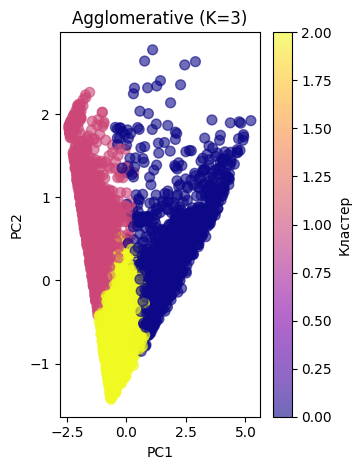

In [ ]:
# График 2: Agglomerative с K=3 для сравнения
plt.subplot(1, 2, 2)
scatter = plt.scatter(rfm_table_cleaned['PC1'],
                      rfm_table_cleaned['PC2'],
                      c=rfm_table_cleaned['cluster_hc'],
                      cmap='plasma',
                      alpha=0.6,
                      s=50)
plt.colorbar(scatter, label='Кластер')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Agglomerative (K=3)')

plt.tight_layout()
plt.show()

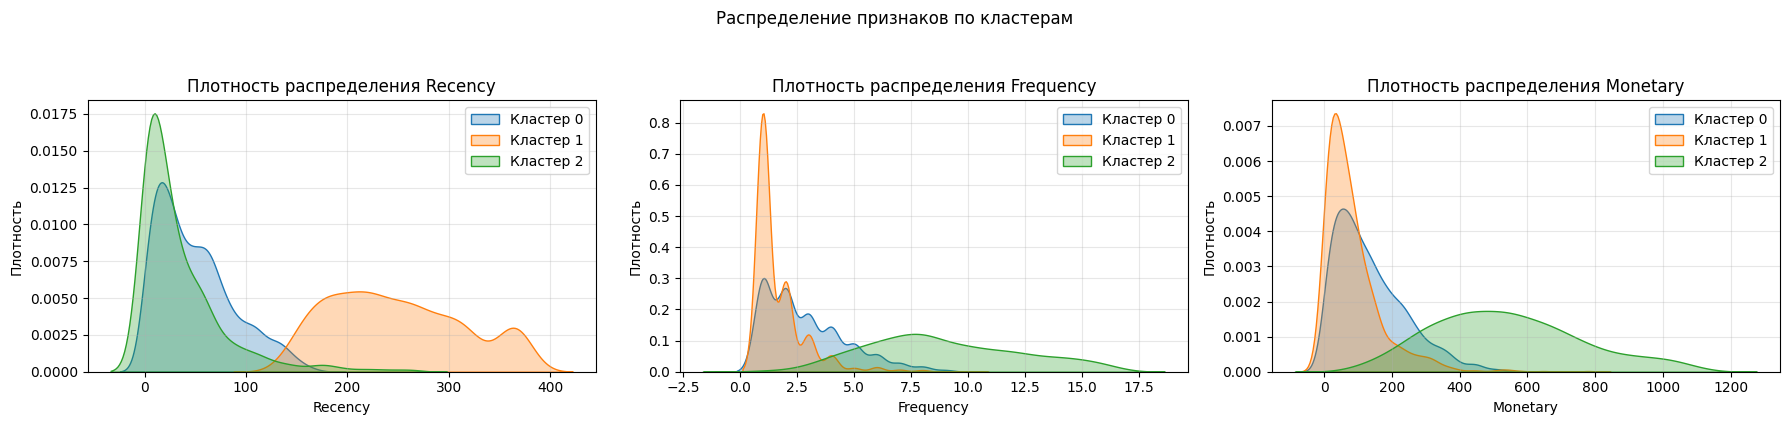

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, feature in enumerate(features):
    for cluster in sorted(rfm_table_cleaned['cluster_km'].unique()):
        subset = rfm_table_cleaned[rfm_table_cleaned['cluster_km'] == cluster]
        sns.kdeplot(data=subset, x=feature, ax=axes[i], label=f'Кластер {cluster}', fill=True, alpha=0.3)
    axes[i].set_title(f'Плотность распределения {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Плотность')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
plt.suptitle('Распределение признаков по кластерам', y=1.05)
plt.tight_layout()
plt.show()

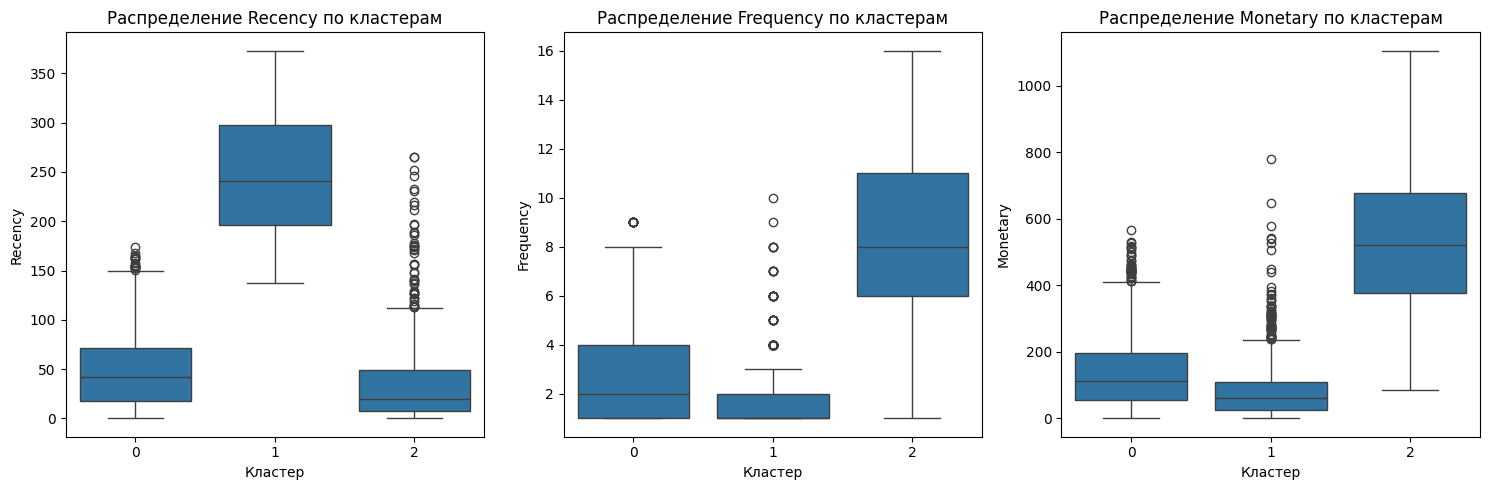

In [ ]:
# лучшая модель KMeans_K=3

# Признаки для анализа
features = ['Recency', 'Frequency', 'Monetary']

# Боксплоты для каждого признака
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(features):
    # Нормализуем данные для наглядности
    sns.boxplot(x='cluster_km', y=feature, data=rfm_table_cleaned, ax=axes[i])
    axes[i].set_title(f'Распределение {feature} по кластерам')
    axes[i].set_xlabel('Кластер')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

In [ ]:
# Описание сегментов клиентов


# Рассчитываем статистику по каждому кластеру
cluster_stats = rfm_table_cleaned.groupby('cluster_km').agg({
    'Recency': ['mean', 'median', 'std'],
    'Frequency': ['mean', 'median', 'std'],
    'Monetary': ['mean', 'median', 'std']
}).round(2)

print("Подробная статистика по кластерам:")
print(cluster_stats)

print("\n" + "="*60)
print("ОПИСАНИЕ СЕГМЕНТОВ КЛИЕНТОВ")
print("="*60)

# Анализируем каждый кластер
for cluster in sorted(rfm_table_cleaned['cluster_km'].unique()):
    cluster_data = rfm_table_cleaned[rfm_table_cleaned['cluster_km'] == cluster]

    # Средние значения
    mean_r = cluster_data['Recency'].mean()
    mean_f = cluster_data['Frequency'].mean()
    mean_m = cluster_data['Monetary'].mean()

    print(f"\nКластер {cluster}: {len(cluster_data)} клиентов ({len(cluster_data)/len(rfm_table_cleaned)*100:.1f}%)")
    print("-" * 50)
    print(f"  • Recency (давность): {mean_r:.1f} дней")
    print(f"  • Frequency (частота): {mean_f:.1f} покупок")
    print(f"  • Monetary (сумма): {mean_m:.0f} руб.")

    # Характеристика сегмента
    if mean_r < cluster_stats['Recency']['mean'].min() + cluster_stats['Recency']['mean'].std():
        recency_desc = "🟢 НЕДАВНИЕ покупки"
    elif mean_r > cluster_stats['Recency']['mean'].max() - cluster_stats['Recency']['mean'].std():
        recency_desc = "🔴 ДАВНО не покупали"
    else:
        recency_desc = "🟡 СРЕДНЯЯ давность"

    if mean_f > cluster_stats['Frequency']['mean'].max() - cluster_stats['Frequency']['mean'].std():
        freq_desc = "🟢 ЧАСТЫЕ покупки"
    elif mean_f < cluster_stats['Frequency']['mean'].min() + cluster_stats['Frequency']['mean'].std():
        freq_desc = "🔴 РЕДКИЕ покупки"
    else:
        freq_desc = "🟡 СРЕДНЯЯ частота"

    if mean_m > cluster_stats['Monetary']['mean'].max() - cluster_stats['Monetary']['mean'].std():
        monetary_desc = "🟢 ВЫСОКИЙ чек"
    elif mean_m < cluster_stats['Monetary']['mean'].min() + cluster_stats['Monetary']['mean'].std():
        monetary_desc = "🔴 НИЗКИЙ чек"
    else:
        monetary_desc = "🟡 СРЕДНИЙ чек"

    print(f"  • Характеристика: {recency_desc}, {freq_desc}, {monetary_desc}")

Подробная статистика по кластерам:
           Recency               Frequency              Monetary          \
              mean median    std      mean median   std     mean  median   
cluster_km                                                                 
0            49.48   42.0  37.83      2.85    2.0  1.80   135.60  111.64   
1           249.19  241.0  65.30      1.68    1.0  1.19    84.23   60.73   
2            34.70   20.0  42.55      8.90    8.0  3.36   539.01  521.78   

                    
               std  
cluster_km          
0           103.82  
1            87.38  
2           218.85  

ОПИСАНИЕ СЕГМЕНТОВ КЛИЕНТОВ

Кластер 0: 2270 клиентов (55.8%)
--------------------------------------------------
  • Recency (давность): 49.5 дней
  • Frequency (частота): 2.9 покупок
  • Monetary (сумма): 136 руб.
  • Характеристика: 🟢 НЕДАВНИЕ покупки, 🔴 РЕДКИЕ покупки, 🔴 НИЗКИЙ чек

Кластер 1: 988 клиентов (24.3%)
--------------------------------------------------
  • Recency

**Ответ**:

- Кластер 0 - **Обычные клиенты / Средний сегмент**: клиенты, покупающие регулярно (малое значение `Recency`), достаточно мало (малое значение `Frequency`) и дешево (малое значение `Monetary`)

- Кластер 1 - **Неактивные / Рискующие уйти**: клиенты, покупающие очень редко (большое значение `Recency`), мало (малое значение `Frequency`) и дешево (малое значение `Monetary`)

- Кластер 2 - **Лояльные клиенты / VIP клиенты**: клиенты, покупающие очень часто (малое значение `Recency`) и больше (большое значение `Frequency`) остальных, и тратящие деньги больше (большое значение `Monetary`)

#### **Шаг 6: Формирование бизнес-рекомендаций**

**6.1. Анализ потребностей каждого сегмента:**

- Определите потребности и предпочтения клиентов в каждом сегменте.
- Выявите возможности для увеличения продаж и улучшения сервиса.

**6.2. Разработка стратегий для каждого сегмента:**

- **Маркетинговые кампании:**
  - Персонализированные предложения.
  - Программы лояльности для удержания ценных клиентов.
- **Оптимизация продуктов:**
  - Расширение ассортимента для популярных сегментов.
  - Фокус на продуктах, интересных конкретным сегментам.

**6.3. Оценка потенциального влияния:**

- Оцените, как предложенные стратегии могут повысить выручку, удовлетворенность клиентов и другие ключевые показатели.

Ответ

### 6.1 Анализ потребностей клиентских сегментов

#### Кластер 0 — «Обычные клиенты» (55,8%)

Основные потребности:
- Выгодные предложения и скидки на товары повседневного спроса, которые приобретаются на регулярной основе.
- Высокая чувствительность к ценам, акциям и специальным предложениям.
- Дополнительная мотивация для увеличения частоты покупок.
- Низкий уровень приверженности бренду: при появлении более выгодных условий у конкурентов могут легко сменить продавца.

Возможности для развития сегмента:
- Внедрение программ лояльности с накоплением бонусных баллов, повышенным кэшбэком или системой уровней, предусматривающей дополнительные привилегии.
- Использование реферальных механик, позволяющих получать бонусы как действующему клиенту, так и приглашённому пользователю.
- Проведение регулярных персонализированных акций для повышения вовлечённости и формирования долгосрочной лояльности.

#### Кластер 1 — «Неактивные клиенты / Клиенты с высоким риском оттока» (24,3%)

Основные потребности:
- Данная группа характеризуется высокой вероятностью прекращения взаимодействия с компанией.
- Для возврата клиентов необходимы существенные стимулы, побуждающие совершить повторную покупку.
- Возможными причинами снижения активности могут быть переход к конкурентам, неудовлетворённость сервисом или потеря интереса к предложениям компании.

Возможности для развития сегмента:
- Реализация персонализированных маркетинговых кампаний с индивидуальными скидками и специальными предложениями.
- Использование бонусов за возвращение, промокодов и ограниченных по времени акций.
- Проведение опросов для выявления причин снижения активности и последующей корректировки стратегии удержания.

#### Кластер 2 — «Лояльные клиенты / VIP-клиенты» (19,9%)

Основные потребности:
- Персонализированный подход, включающий индивидуальные рекомендации и специальные предложения.
- Получение эксклюзивных преимуществ и подтверждение своего особого статуса.
- Высокое качество обслуживания, оперативность и удобство взаимодействия с компанией.
- Доступ к новым продуктам и премиальным предложениям раньше остальных клиентов.

Возможности для развития сегмента:
- Развитие VIP-программ с расширенным набором привилегий и персональных условий обслуживания.
- Организация закрытых распродаж, эксклюзивных мероприятий и раннего доступа к новым продуктам.
- Увеличение среднего чека за счёт кросс-продаж и продвижения премиальных товаров, поскольку данный сегмент демонстрирует высокий уровень доверия к компании.

### 6.2 Разработка стратегий взаимодействия с клиентскими сегментами

#### Кластер 0 — «Обычные клиенты» (55,8%)

Маркетинговые мероприятия:
- Внедрение накопительной системы лояльности, предусматривающей увеличение размера скидки по мере роста числа совершённых покупок.
- Использование триггерных коммуникаций для реактивации клиентов, например предоставление персональной скидки при длительном отсутствии покупок.
- Проведение стимулирующих акций, направленных на увеличение объёма заказа, таких как специальные предложения при покупке нескольких товаров.
- Разработка реферальной программы, предполагающей вознаграждение клиентов за привлечение новых покупателей.

Оптимизация продуктового предложения:
- Формирование комплектов взаимодополняющих товаров по специальной цене для повышения среднего чека.
- Создание отдельной категории товаров низкой ценовой категории, ориентированной на стимулирование импульсивных покупок.
- Регулярное обновление акционных предложений на наиболее востребованные товары.

#### Кластер 1 — «Неактивные клиенты / Клиенты с высоким риском оттока» (24,3%)

Маркетинговые мероприятия:
- Реализация программ реактивации с использованием персонализированных предложений и поэтапного увеличения размера скидки.
- Предоставление специальных бонусов или подарков за возвращение к покупкам.
- Проведение коммуникационных кампаний с напоминанием о накопленных бонусах и доступных преимуществах программы лояльности.
- Организация опросов для выявления причин снижения активности клиентов с последующим предоставлением небольшого вознаграждения за участие.

Оптимизация продуктового предложения:
- Предоставление бесплатной доставки при первой покупке после периода неактивности.
- Использование специальных скидок при достижении установленного порога суммы заказа.
- Формирование персонализированных подборок товаров на основе истории предыдущих покупок клиента.

#### Кластер 2 — «Лояльные клиенты / VIP-клиенты» (19,9%)

Маркетинговые мероприятия:
- Разработка многоуровневой программы лояльности с эксклюзивными привилегиями для наиболее ценных клиентов.
- Предоставление персонализированных предложений, учитывающих предпочтения и историю покупок клиента.
- Организация закрытых распродаж, специальных мероприятий и раннего доступа к новым продуктам.
- Начисление повышенного кэшбэка и дополнительных бонусов в качестве поощрения за высокий уровень активности.

Оптимизация продуктового предложения:
- Расширение ассортимента премиальных товаров и эксклюзивных продуктовых линеек.
- Внедрение сервиса персонального сопровождения покупателей для предоставления индивидуальных рекомендаций и повышения качества обслуживания.
- Предоставление возможности предварительного заказа и раннего доступа к новым товарам.
- Использование инструментов кросс-продаж и апселлинга для увеличения среднего чека и укрепления долгосрочных отношений с клиентами.

**6.3. Оценка потенциального влияния**

| Что получим | Как это работает |
|-------------|---------------|
| **Индивидуальный подход к клиенту** | Персонализация и удобство вызывают больше доверия, это увеличивает количество покупок и рост среднего чека |
| **Возвращение части «неактивных» клиентов** | Главное - затащить неактивного клиента в магазин и создать иллюзию выгодности и эксклюзивности предложения.<br>Своевременные напоминания и выгодные предложения стимулируют людей снова совершать покупки, а не уходить к конкурентам |
| **Увеличение прибыли с каждого клиента** | Программы лояльности и персональные предложения на основе предпочтений стимулируют людей из каждой категории покупать чаще и больше|
| **Прирост новых клиентов без затрат на рекламу** | Обычные и VIP клиенты расскажут о магазине знакомым |


#### **Шаг 7: Документирование и презентация результатов**

# 7.1. Подготовка отчета

## Введение

В современных условиях высокой конкуренции компании розничной торговли стремятся не только привлекать новых покупателей, но и эффективно удерживать существующих клиентов. Для повышения объема продаж и прибыли необходимо глубокое понимание потребительского поведения, анализ покупательской активности и выявление закономерностей в действиях клиентов.

Одним из наиболее эффективных инструментов решения данной задачи является сегментация клиентов с использованием методов машинного обучения. Сегментация позволяет разделить покупателей на группы со схожими характеристиками и особенностями поведения. Полученные сегменты могут использоваться для разработки персонализированных маркетинговых стратегий, повышения эффективности рекламных кампаний и оптимизации бизнес-процессов компании.

Целью данной работы является разработка модели кластеризации клиентов на основе алгоритмов машинного обучения с использованием данных розничной компании для проведения углубленного анализа клиентской базы и формирования практических рекомендаций по повышению эффективности бизнеса.

## Методология исследования

Исследование включало несколько последовательных этапов.

### 1. Сбор и анализ данных

В качестве источника данных использовался набор данных Online Retail II, содержащий информацию о транзакциях клиентов компании розничной торговли.

### 2. Предобработка данных

На этапе подготовки данных были выполнены:
- обработка пропущенных значений;
- удаление аномальных наблюдений;
- нормализация признаков;
- формирование RFM-характеристик клиентов.

Для анализа использовались следующие показатели:

- Recency (давность) — количество дней с момента последней покупки;
- Frequency (частота) — число совершённых покупок за анализируемый период;
- Monetary (денежная ценность) — суммарный объём покупок клиента.

### 3. Кластеризация клиентов

Для сегментации покупателей были исследованы несколько алгоритмов машинного обучения:

- K-Means;
- Агломеративная кластеризация (Agglomerative Clustering);
- DBSCAN (Density-Based Spatial Clustering of Applications with Noise).

### 4. Оценка качества кластеризации

Качество полученных кластеров оценивалось с использованием внутренних метрик кластеризации:

- коэффициента силуэта (Silhouette Score);
- индекса Дэвиса—Болдина (Davies-Bouldin Index);
- индекса Калинского—Харабаза (Calinski-Harabasz Index).

Все метрики были рассчитаны средствами библиотеки Scikit-learn.

### 5. Интерпретация и визуализация результатов

Полученные результаты были визуализированы с использованием библиотек Matplotlib, Seaborn и Plotly Express. По результатам сравнительного анализа наилучшее качество кластеризации продемонстрировала модель K-Means с количеством кластеров, равным трём.

На основе RFM-характеристик были выделены три основные группы клиентов:
- обычные клиенты;
- неактивные клиенты с высоким риском оттока;
- лояльные (VIP) клиенты.

### 6. Разработка бизнес-рекомендаций

На основании характеристик выявленных сегментов были определены их основные потребности и предложены маркетинговые стратегии, направленные на повышение лояльности клиентов, увеличение среднего чека и снижение уровня оттока.

## Результаты исследования

Сравнение алгоритмов кластеризации показало, что наилучшие результаты были получены при использовании метода K-Means с тремя кластерами. Данная модель обеспечила наиболее высокие значения коэффициента силуэта и продемонстрировала хорошую разделимость клиентских групп.

В результате анализа были выделены следующие сегменты:

1. Обычные клиенты — 55,8%;
2. Неактивные клиенты с высоким риском оттока — 24,3%;
3. Лояльные (VIP) клиенты — 19,9%.

Полученные группы обладают различными поведенческими характеристиками и требуют применения разных подходов к взаимодействию.

## Обсуждение результатов

Проведённая кластеризация позволила успешно выявить ключевые сегменты клиентской базы и определить особенности их покупательского поведения.

Наиболее эффективным алгоритмом оказался K-Means при количестве кластеров, равном трём. Агломеративная кластеризация продемонстрировала близкие результаты, однако уступила K-Means по совокупности используемых метрик. Алгоритм DBSCAN показал существенно более низкое качество сегментации, что связано с особенностями распределения клиентов в пространстве признаков.

Полученные результаты подтверждают возможность применения методов машинного обучения для решения практических задач клиентской аналитики и поддержки принятия маркетинговых решений.

## Рекомендации

### Кластер 0 — Обычные клиенты

Для данного сегмента рекомендуется использовать программы лояльности, накопительные скидки и реферальные механики. Дополнительный эффект могут дать комплектные предложения товаров и специальные акции, стимулирующие увеличение частоты покупок.

### Кластер 1 — Неактивные клиенты

Основной задачей является предотвращение окончательного оттока клиентов. Для этого рекомендуется применять персонализированные предложения, бонусы за возвращение, бесплатную доставку и специальные скидки на повторные покупки.

### Кластер 2 — Лояльные (VIP) клиенты

Для удержания наиболее ценных клиентов рекомендуется развивать VIP-программы, предоставлять эксклюзивные привилегии, организовывать закрытые распродажи и предлагать персонализированный сервис. Дополнительным направлением работы может стать продвижение премиальных товаров и увеличение среднего чека за счёт персональных рекомендаций.

## Заключение

В ходе работы была разработана модель сегментации клиентов на основе RFM-анализа и алгоритмов кластеризации. Проведённое исследование позволило выделить три основные группы покупателей, отличающиеся уровнем активности, лояльности и покупательской ценности.

Полученные результаты могут быть использованы для повышения эффективности маркетинговых кампаний, увеличения среднего чека, стимулирования повторных покупок и снижения уровня клиентского оттока. Разработанные рекомендации создают основу для формирования персонализированных стратегий взаимодействия с различными сегментами клиентов и способствуют повышению общей эффективности бизнес-процессов компании.

7.2. Презентация:

Подготовьте слайды для представления ключевых моментов работы.
Используйте визуализации для иллюстрации результатов.